In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
sales =pd.read_csv("retail_sales.csv")


In [3]:
sales.head(6)

,OrderID,OrderDate,ShipDate,ShipMode,Channel,CustomerID,CustomerName,Email,Phone,Age,...,UnitPrice,Discount,PromoCode,Sales,Cost,Profit,ProfitMargin,PaymentMethod,SalesRep,Returned
0,ORD-1005371,2021-01-01,2021-01-06,Standard,Phone Order,CUST-104055,Chloe Nguyen,chloe.nguyen5@outlook.com,+1-727-573-1855,51,...,130.75,0.05,NEWYEAR,993.70,577.76,415.94,41.86,Debit Card,Jessica A.,No
1,ORD-1005791,2021-01-01,2021-01-07,Standard,Online,CUST-101234,Richard Gonzalez,richard.gonzalez57@hotmail.com,+1-647-352-2293,40,...,185.55,0.15,NEWYEAR,157.72,130.39,27.33,17.33,Apple Pay,Ananya D.,No
2,ORD-1008078,2021-01-01,2021-01-07,Standard,Phone Order,CUST-105358,Barbara Smith,barbara.smith1996@proton.me,+1-500-343-1036,56,...,40.12,0.00,NaN,40.12,19.63,20.49,51.07,Debit Card,Liam C.,No
3,ORD-1009062,2021-01-01,2021-01-08,Standard,Phone Order,CUST-103845,Sarah Sharma,sarahsharma1975@company.com,+1-471-298-3265,34,...,4.82,0.00,NaN,19.28,7.24,12.04,62.45,Debit Card,Diego S.,No
4,ORD-1009733,2021-01-01,2021-01-06,Standard,Mobile App,CUST-102577,Karen Miller,karen.miller24@hotmail.com,+1-308-547-5047,55,...,39.79,0.00,NaN,39.79,22.91,16.88,42.42,Credit Card,Priya C.,No
5,ORD-1010612,2021-01-01,2021-01-05,First Class,In-Store,CUST-101525,Richard Murphy,richard_murphy@hotmail.com,+1-546-432-1660,46,...,553.97,0.00,NaN,553.97,499.46,54.51,9.84,Bank Transfer,Wei K.,No


In [4]:
sales.info()
sales.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        80000 non-null  object 
 1   OrderDate      80000 non-null  object 
 2   ShipDate       80000 non-null  object 
 3   ShipMode       80000 non-null  object 
 4   Channel        80000 non-null  object 
 5   CustomerID     80000 non-null  object 
 6   CustomerName   80000 non-null  object 
 7   Email          80000 non-null  object 
 8   Phone          80000 non-null  object 
 9   Age            80000 non-null  int64  
 10  Gender         80000 non-null  object 
 11  Segment        80000 non-null  object 
 12  LoyaltyTier    80000 non-null  object 
 13  Region         80000 non-null  object 
 14  Country        80000 non-null  object 
 15  State          80000 non-null  object 
 16  City           80000 non-null  object 
 17  PostalCode     80000 non-null  object 
 18  Catego

OrderID              0
OrderDate            0
ShipDate             0
ShipMode             0
Channel              0
CustomerID           0
CustomerName         0
Email                0
Phone                0
Age                  0
Gender               0
Segment              0
LoyaltyTier          0
Region               0
Country              0
State                0
City                 0
PostalCode           0
Category             0
SubCategory          0
ProductID            0
ProductName          0
Quantity             0
UnitPrice            0
Discount             0
PromoCode        63114
Sales                0
Cost                 0
Profit               0
ProfitMargin         0
PaymentMethod        0
SalesRep             0
Returned             0
dtype: int64

In [5]:
sales = sales.drop_duplicates()

In [6]:
sales["OrderDate"] = pd.to_datetime(sales["OrderDate"], errors='coerce')
sales["OrderDate"] = sales["OrderDate"].dt.strftime("%Y-%m-%d")

In [7]:
sales.columns

Index(['OrderID', 'OrderDate', 'ShipDate', 'ShipMode', 'Channel', 'CustomerID',
       'CustomerName', 'Email', 'Phone', 'Age', 'Gender', 'Segment',
       'LoyaltyTier', 'Region', 'Country', 'State', 'City', 'PostalCode',
       'Category', 'SubCategory', 'ProductID', 'ProductName', 'Quantity',
       'UnitPrice', 'Discount', 'PromoCode', 'Sales', 'Cost', 'Profit',
       'ProfitMargin', 'PaymentMethod', 'SalesRep', 'Returned'],
      dtype='object')

In [8]:
sales["OrderDate"] = pd.to_datetime(sales["OrderDate"], errors='coerce')
sales["OrderDate"] = sales["OrderDate"].dt.strftime("%Y-%m-%d")

sales["ShipDate"] = pd.to_datetime(sales["ShipDate"], errors='coerce')
sales["ShipDate"] = sales["ShipDate"].dt.strftime("%Y-%m-%d")


In [9]:
cols = ["Sales", "Cost", "Profit", "UnitPrice"]

for col in cols:
    sales[col] = sales[col].replace('[\$,]', '', regex=True).astype(float)
    

In [20]:
sales["Segment"] = sales["Segment"].str.strip().str.lower()

sales["Segment"] = sales["Segment"].replace({
    "consumer": "Consumer",
    "corporate": "Corporate",
    "home office": "Home Office"
})


In [21]:
sales["Returned"] = sales["Returned"].str.strip().str.lower()

sales["Returned"] = sales["Returned"].replace({
    "yes": "Yes",
    "y": "Yes",
    "no": "No",
    "n": "No"
})

In [12]:
sales.isnull().sum()

OrderID              0
OrderDate            0
ShipDate             0
ShipMode             0
Channel              0
CustomerID           0
CustomerName         0
Email                0
Phone                0
Age                  0
Gender               0
Segment              0
LoyaltyTier          0
Region               0
Country              0
State                0
City                 0
PostalCode           0
Category             0
SubCategory          0
ProductID            0
ProductName          0
Quantity             0
UnitPrice            0
Discount             0
PromoCode        63114
Sales                0
Cost                 0
Profit               0
ProfitMargin         0
PaymentMethod        0
SalesRep             0
Returned             0
dtype: int64

In [24]:
sales["Sales"].fillna(sales["Sales"].mean(), inplace=True)
sales["Profit"].fillna(sales["Profit"].mean(), inplace=True)

In [25]:
sales["Segment"].fillna("Unknown", inplace=True)
sales["Category"].fillna("Unknown", inplace=True)

In [26]:
sales = sales.dropna(subset=["OrderDate"])

In [27]:
sales = sales[sales["Quantity"] > 0]

In [28]:
sales = sales.drop_duplicates()

In [29]:
sales.to_csv("retail_sales_clean.csv", index=False)

In [30]:
sales["ProfitMargin"] = pd.to_numeric(sales["ProfitMargin"], errors='coerce')
sales["Discount"] = pd.to_numeric(sales["Discount"], errors='coerce')

In [33]:
sales.isnull().sum()

OrderID          0
OrderDate        0
ShipDate         0
ShipMode         0
Channel          0
CustomerID       0
CustomerName     0
Email            0
Phone            0
Age              0
Gender           0
Segment          0
LoyaltyTier      0
Region           0
Country          0
State            0
City             0
PostalCode       0
Category         0
SubCategory      0
ProductID        0
ProductName      0
Quantity         0
UnitPrice        0
Discount         0
PromoCode        0
Sales            0
Cost             0
Profit           0
ProfitMargin     0
PaymentMethod    0
SalesRep         0
Returned         0
dtype: int64

In [32]:
for col in sales.select_dtypes(include='object').columns:
    print(f"\nColumn:'{col}'")
    sales[col]=sales[col].fillna(sales[col].mode()[0])


Column:'OrderID'

Column:'OrderDate'

Column:'ShipDate'

Column:'ShipMode'

Column:'Channel'

Column:'CustomerID'

Column:'CustomerName'

Column:'Email'

Column:'Phone'

Column:'Gender'

Column:'Segment'

Column:'LoyaltyTier'

Column:'Region'

Column:'Country'

Column:'State'

Column:'City'

Column:'PostalCode'

Column:'Category'

Column:'SubCategory'

Column:'ProductID'

Column:'ProductName'

Column:'PromoCode'

Column:'PaymentMethod'

Column:'SalesRep'

Column:'Returned'


In [34]:
sales["OrderDate"] = pd.to_datetime(sales["OrderDate"], errors='coerce')
sales["ShipDate"] = pd.to_datetime(sales["ShipDate"], errors='coerce')

In [35]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        80000 non-null  object        
 1   OrderDate      80000 non-null  datetime64[ns]
 2   ShipDate       80000 non-null  datetime64[ns]
 3   ShipMode       80000 non-null  object        
 4   Channel        80000 non-null  object        
 5   CustomerID     80000 non-null  object        
 6   CustomerName   80000 non-null  object        
 7   Email          80000 non-null  object        
 8   Phone          80000 non-null  object        
 9   Age            80000 non-null  int64         
 10  Gender         80000 non-null  object        
 11  Segment        80000 non-null  object        
 12  LoyaltyTier    80000 non-null  object        
 13  Region         80000 non-null  object        
 14  Country        80000 non-null  object        
 15  State          8000

In [37]:
sales.to_csv("retail_sales_cleaned.csv", index=False)

In [38]:
sales["Year"] = sales["OrderDate"].dt.year
sales["Month"] = sales["OrderDate"].dt.month

In [39]:
monthly_sales = sales.groupby(["Year", "Month"])["Sales"].sum().reset_index()
monthly_sales

,Year,Month,Sales
0,2021,1,576139.91
1,2021,2,438628.99
2,2021,3,540276.15
3,2021,4,474304.46
4,2021,5,572600.52
5,2021,6,578229.45
6,2021,7,537749.51
7,2021,8,501428.42
8,2021,9,515556.48
9,2021,10,468880.83


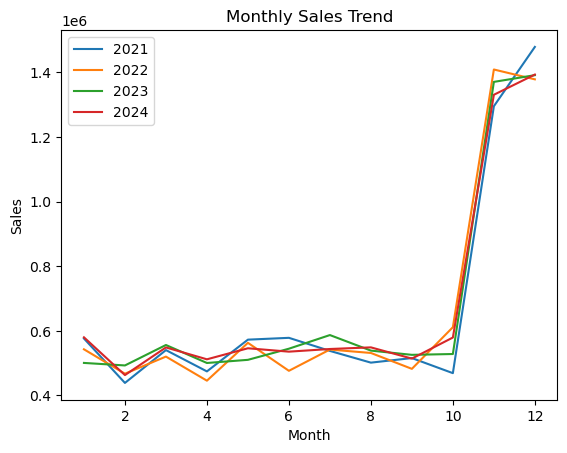

In [40]:
import matplotlib.pyplot as plt

plt.figure()
for year in monthly_sales["Year"].unique():
    data = monthly_sales[monthly_sales["Year"] == year]
    plt.plot(data["Month"], data["Sales"], label=year)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.legend()
plt.show()

In [42]:
region_analysis = sales.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
region_analysis

,Region,Sales,Profit
0,Asia-Pacific,6427739.48,1867876.77
1,Europe,6507017.00,1903391.75
2,North America - Central,6233644.24,1834670.44
3,North America - East,6533700.59,1931001.79
4,North America - West,6383961.08,1880199.28


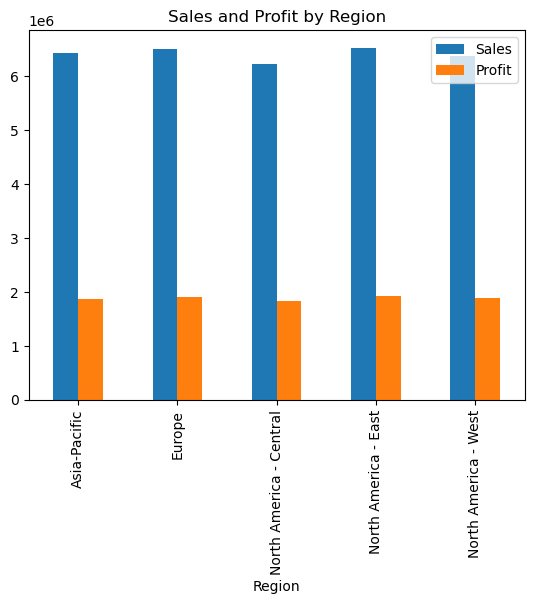

In [43]:
region_analysis.plot(x="Region", y=["Sales", "Profit"], kind="bar")
plt.title("Sales and Profit by Region")
plt.show()

In [44]:
category_sales = sales.groupby("Category")["Sales"].sum().reset_index()
category_sales

,Category,Sales
0,Clothing,2703476.46
1,Furniture,8272681.62
2,Office Supplies,762159.85
3,Sports & Outdoors,2874805.21
4,Technology,17472939.25


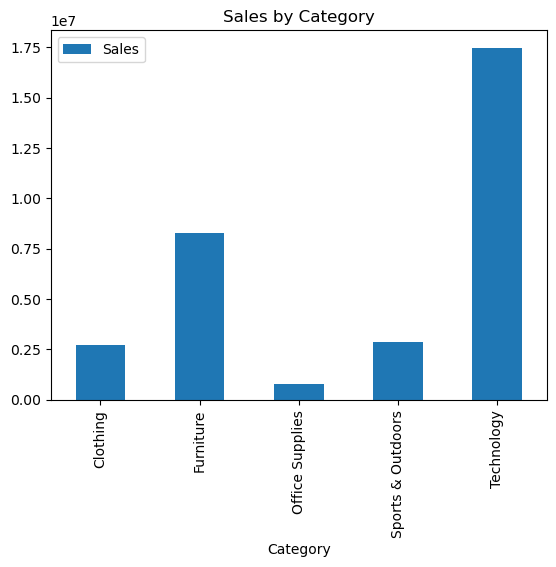

In [45]:
category_sales.plot(x="Category", y="Sales", kind="bar")
plt.title("Sales by Category")
plt.show()

In [46]:

subcat_sales = sales.groupby("SubCategory")["Sales"].sum().reset_index()
subcat_sales = subcat_sales.sort_values(by="Sales", ascending=False)
subcat_sales

,SubCategory,Sales
11,Laptops,7849851.12
18,Smartphones,5086924.42
20,Tables,4031853.95
3,Bookcases,2044836.53
13,Monitors,1737193.92
4,Camping,1682745.21
5,Chairs,1487838.29
17,Printers,1428694.77
14,Networking,1014569.70
8,Footwear,938599.24


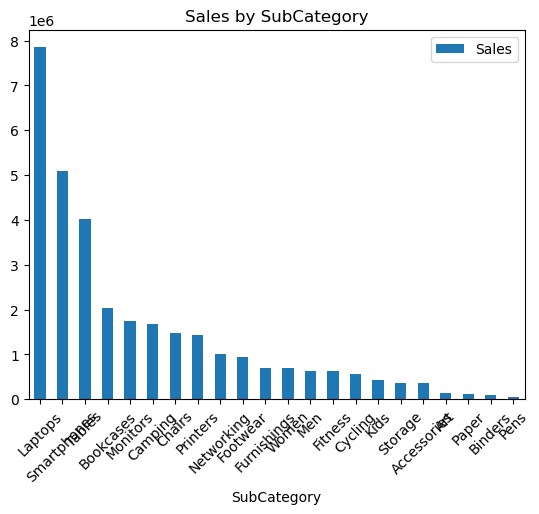

In [47]:
subcat_sales.plot(x="SubCategory", y="Sales", kind="bar")
plt.title("Sales by SubCategory")
plt.xticks(rotation=45)
plt.show()

In [49]:
yearly_sales = sales.groupby("Year")["Sales"].sum().reset_index()
yearly_sales
yearly_sales["YoY Growth (%)"] = yearly_sales["Sales"].pct_change() * 100
yearly_sales

,Year,Sales,YoY Growth (%)
0,2021,7977893.29,NaN
1,2022,7968706.58,-0.115152
2,2023,8045618.77,0.965178
3,2024,8093843.75,0.599394


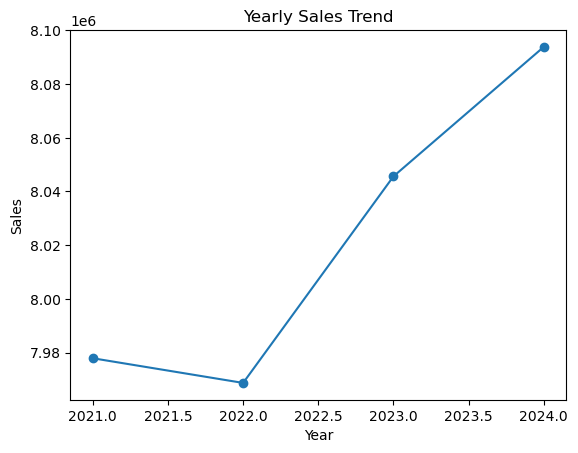

In [50]:
plt.figure()
plt.plot(yearly_sales["Year"], yearly_sales["Sales"], marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [51]:
total_revenue = sales["Sales"].sum()
total_profit = sales["Profit"].sum()

profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Profit Margin (%):", profit_margin)

Total Revenue: 32086062.39
Total Profit: 9417140.030000001
Profit Margin (%): 29.349628245237607


In [52]:
total_orders = sales["OrderID"].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", aov)

Average Order Value: 401.075779875


In [53]:
top_customers = sales.groupby("CustomerName")["Sales"].sum().reset_index()

top_customers = top_customers.sort_values(by="Sales", ascending=False).head(10)

top_customers

,CustomerName,Sales
794,Linda Hernandez,65371.28
576,James Wilson,64102.85
1058,Noah Brown,62408.51
801,Linda Martinez,61525.28
1460,Thomas Tanaka,60230.78
1503,William Costa,59843.27
81,Ananya Jones,59686.53
823,Lucas Chen,58255.38
583,Jennifer Cohen,57517.97
1385,Sofia Reyes,57374.76


In [54]:
total_orders = sales["OrderID"].count()
returned_orders = sales[sales["Returned"] == "Yes"]["OrderID"].count()

return_rate = (returned_orders / total_orders) * 100

print("Return Rate (%):", return_rate)

Return Rate (%): 4.12875


In [55]:
customer_orders = sales.groupby("CustomerID")["OrderID"].nunique()

repeat_customers = customer_orders[customer_orders > 1].count()
total_customers = customer_orders.count()

repeat_rate = (repeat_customers / total_customers) * 100

print("Repeat Customer Rate (%):", repeat_rate)

Repeat Customer Rate (%): 99.98333333333333


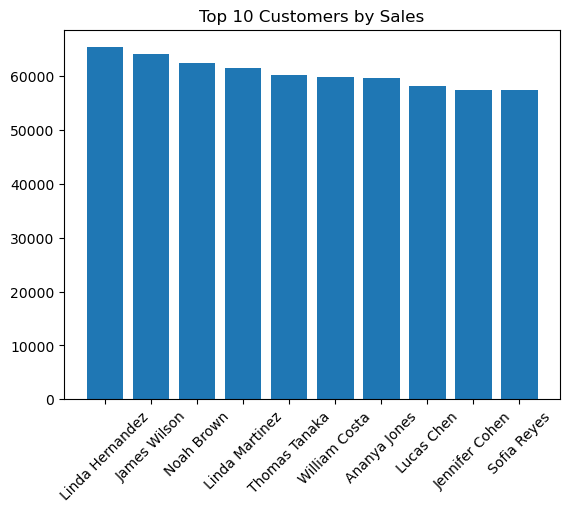

In [56]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(top_customers["CustomerName"], top_customers["Sales"])
plt.xticks(rotation=45)
plt.title("Top 10 Customers by Sales")
plt.show()